In [1]:
import numpy as np
import mujoco
import mediapy as media
import matplotlib.pyplot as plt
import os
import math

In [2]:
work_dir = os.getcwd()
# xml_path = work_dir + r"\worm_modeling\worm_friction_test.xml"
xml_path = work_dir + r"\worm_modeling\friction_platform.xml"
model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

mujoco.mj_forward(model, data)

In [3]:
renderer = mujoco.Renderer(model, 400, 900)
renderer.update_scene(data, camera='fixed')

""

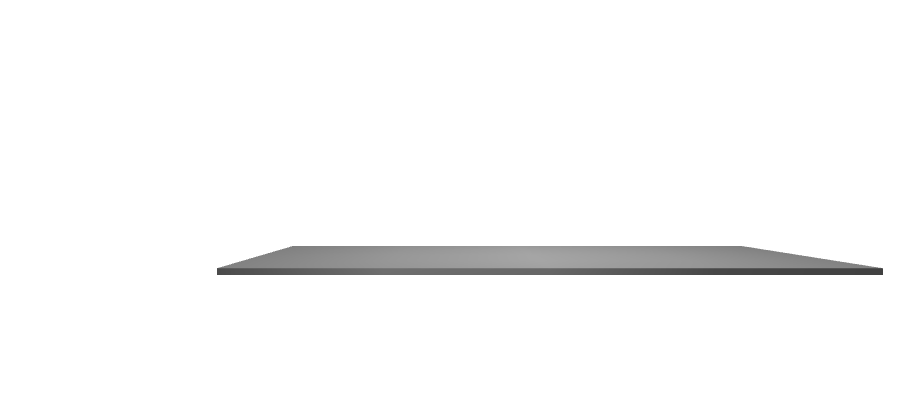

In [4]:
media.show_image(renderer.render())

In [5]:
tmax = 15
dt = 0.1/1000
t = np.arange(0, tmax, dt)

model.opt.timestep = dt

In [6]:
frames = []
framerate = 60

max_act = -0.6
ctrl_ramp = np.ones(len(t))*max_act
ctrl_ramp[0:int(len(t)*0.5)] = np.linspace(0,max_act,int(len(t)*0.5))

platform_angle = np.zeros(np.size(t))
actuator_id = mujoco.mj_name2id(model,mujoco.mjtObj.mjOBJ_ACTUATOR,"plat_motor")
joint_id = mujoco.mj_name2id(model,mujoco.mjtObj.mjOBJ_JOINT,"angler")

for i in range(len(t)):

    data.ctrl[actuator_id] = ctrl_ramp[i]  # Set the control signal
    mujoco.mj_step(model, data)
    platform_angle[i] = data.qpos[joint_id]
    
    if len(frames) < data.time*framerate:
        renderer.update_scene(data, camera='fixed')
        frames.append(renderer.render().copy())


In [7]:
media.show_video(frames, fps=framerate)

This browser does not support the video tag.


Text(0, 0.5, 'Angle (deg)')

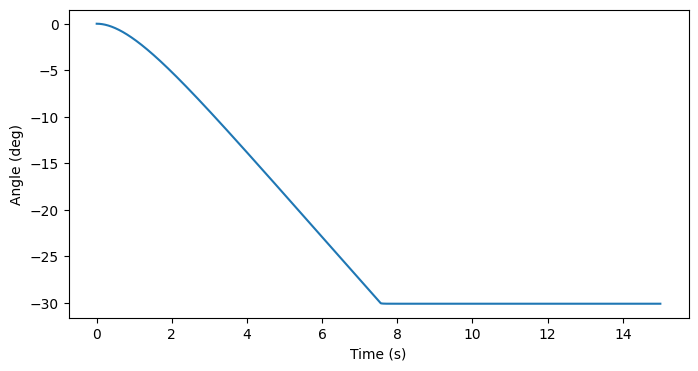

In [8]:
angle = platform_angle*180/np.pi

plt.figure(figsize=(8,4))
plt.plot(t, angle)
plt.xlabel('Time (s)')
plt.ylabel('Angle (deg)')